<a href="https://colab.research.google.com/github/scardenol/Numerical_Analysis_2026/blob/main/Taller%201/1_simplex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 1 - Punto 1

Considere el problema de programación lineal estándar

\begin{gather*}
\max\; c^Tx \quad \text{s.a.} \quad Ax \leq b,\; x \geq 0
\end{gather*}

Donde:
* $c_{n \times 1}$ es el vector de costos o coeficientes de la fucnción objetivo.
* $x_{n \times 1}$ es el vector de variables de decisión.
* $A_{m \times n}$ es la matriz de coeficientes de las restricciones.
* $b_{m \times 1}$ es el vector de disponibilidad de recursos que limita las restricciones.

El objetivo es:
1) Programar el método Simplex que reciba como parámetros de entrada $c$, $A$, $b$.
2) Validar el ejemplo de **La Floristería** de clase.
3) Proponer otro arreglo floral para el ejercicio, agregarlo y solucionarlo.
4) Perturbar los vectores $b$ y $c$ del problema original y proponer un análisis de sensibilidad. Sería interesante poder observar:
    - El área de la región factible.
    - Perturbaciones suficientemente grandes para ver casos de salto de vértices (nuevo óptimo).

In [133]:
# Cargar librerías
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# 1) Método Simplex

Partiendo del problema de programación lineal estándar, se transforman las restricciones de desigualdad a igualdad al usar variables de holgura. Esto resulta en el problema equivalente:

\begin{gather*}
\max\; z= c^Tx \quad \text{s.a.} \quad Ax + s = b,\; x,s \geq 0
\end{gather*}

Donde $s_{m \times 1}$ es el vector de variables de holgura.

Note que:
* Cambian algunas dimensiones: $x_{(m+n)\times 1}$, $A_{m \times (m+n)}$ y $c_{(m+n)\times 1}$. Pero $b_{m \times 1}$ se mantiene igual.
* El sistema lineal en este punto tiene infinitas soluciones.

Por esta razón, pensamos en variables básicas $x_{B_{m \times 1}}$ y no-básicas $x_{N_{n \times 1}}$, buscando que $x_N = 0$ y reduciendo el sistema lineal a un problema de $m$ variables $\times$ $m$ ecuaciones. Esto implica que:
\begin{gather*}
x = [x_B \;|\; x_N]^T, \\
A = [A_B \;|\; A_N], \\
c = [c_B \;|\; c_N]^T,
\end{gather*}
Donde, se puede deducir que
\begin{gather*}
x_B = A_B^{-1}(b-A_N x_N),\\
z = c_B^Tx_B + c_N^Tx_N,\\
y^T = c_B^TA_B^{-1} \quad \text{(vector de precios sombra)}, \\
\bar{c}_j = y^TA_j - c_j \quad \text{(costos reducidos) con $j$ columna de la variable asociada}
\end{gather*}

y, de acuerdo con el **Criterio de Optimalidad**, si todos los costos reducidos de las variables no-básicas son $\geq0$, la solución (base) es óptima.

In [134]:
def simplex(A, b, c, verbose=True):
  """
  Método Simplex para resolver problemas de máximización de programación lineal
  en la forma estándar. Se asume que c,b son np.array 1D y A es np.array 2D.

  Entradas:
  - A: matriz de coeficientes de las restricciones.
  - b: vector de disponibilidad de recursos que limita las restricciones.
  - c: vector de costos o coeficientes de la función objetivo.
  - verbose: flag booleano que determina si se quiere imprimir el progreso del algoritmo.

  Salidas:
  - base: diccionario con la base óptima.
  - z: valor de la función objetivo en la base óptima.
  """
  # Revisar que los objetos sean los esperados con la dimensión esperada
  assert isinstance(A, np.ndarray), "A no es un array de numpy"
  assert isinstance(b, np.ndarray), "b no es un array de numpy"
  assert isinstance(c, np.ndarray), "c no es un array de numpy"

  assert A.ndim == 2, "A no es un array 2D"
  assert b.ndim == 1, "b no es un array1D"
  assert c.ndim == 1, "c no es un array 1D"

  # Extraer dimensiones m y n de la matriz A
  m, n = A.shape

  # Crear nombres para las variables de holgura (s_1, ..., s_m) y de decisión (x_1, ..., x_n)
  nombres = np.array([f"s_{i+1}" for i in range(m)] + [f"x_{j+1}" for j in range(n)])

  # Inicialización
  x_N = np.zeros(n)
  A_B = np.eye(m)
  A_N = A
  c_B = np.zeros(m)
  c_N = c
  A_B_inv = np.linalg.inv(A_B)
  x_B = A_B_inv @ (b - A_N @ x_N)
  iteracion = 0

  # Ciclo while que itera mientras no se haya alcanzado el óptimo
  while True:

    # Objetos con dimensión aumentada
    x = np.concatenate((x_B, x_N))
    A = np.concatenate((A_B, A_N), axis=1)
    c = np.concatenate((c_B, c_N))

    # Evaluar en la función objetivo z = c^Tx
    z = c.T @ x

    # Calcular la base actual
    base = {nombre.item(): round(valor.item(), 2) for nombre, valor in zip(nombres[:m], x_B)}

    # Imprimir progreso
    if verbose:
      print("="*91)
      print("="*40 + f"Iteración {iteracion}" + "="*40)
      print(f"Función objetivo: z = {z}")
      print(f"Base actual: x_B = {base}")

    # Calcular vector de precios sombra y^T = c_B^T A_B^{-1}
    y_T = c_B.T @ A_B_inv

    # Calcular vector de costos reducidos
    c_bar = y_T @ A - c
    print(f"Costos reducidos: c_bar = {np.round(c_bar, 2)}\n") if verbose else None

    # Verificar si la base es óptima (Criterio de Optimalidad) c_bar_N \geq 0
    if np.all(c_bar >= 0):
      # Extraer los valores de x_B asociados a los nombres con "x" y guardarlo
      # en un diccionario con cada nombre

      print(f"Óptimo alcanzado: x* = {base}") if verbose else None
      break
    else: # De lo contrario

      # Elegir el índice del costo reducido más negativo (mínimo)
      j = np.argmin(c_bar)

      # Extraer el elemento j de A
      A_j = A[:, j]

      # Calcular el  nuevo valor de la variable x_j
      v_j = np.divide(A_B_inv @ b, A_B_inv @ A_j) # Vector auxiliar v_j = (A_B_inv b) / (A_B_inv A_j)
      x_j = np.min(v_j) # nuevo valor de la variable x_j
      i = np.argmin(v_j) # índice del mínimo

      # Actualizar la base x_B = A_B^{-1}(b-A_j x_j)
      x_B = A_B_inv @ (b - x_j*A_j)

      # Actualizar vectores con la nueva base
      x_B[i] = x_j # entra la variable j a la base en la posición i
      c_B[i] = c[j] # entra el costo de la variable j en la posición i
      c_N[j-m] = 0 # elimina el costo de la variable j en la posición i

      # Actualizar la matriz A con la nueva base
      A[:, [i, j]] = A[:, [j, i]] # intercambiar columnas i y j de A
      nombres[[i, j]] = nombres[[j, i]] # hacer lo mismo para preservar el orden de los nombres

      A_B = A[:, :m] # extraer A_B
      A_N = A[:, m:] # extraer A_N
      A_B_inv = np.linalg.inv(A_B) # recalcular la inversa

      # Aumentar iteración
      iteracion += 1

  # Retornar los resultados
  return base, z.item()


# 2) Validación: ejemplo de La Floristería

José abrió una floristería que se llama *Chepeflower* que ofrece 2 tipos de arreglos florales $x_1$ y $x_2$ con las siguientes características:

<center>

||$x_1$|$x_2$|Disponibilidad|
|----|:----:|:----:|:----:|
|rosas|3|1|300|
|tulipanes|1|1|140|
|hibisco|1|3|300|
||\$2000|\$1000||

</center>

¿Cuántos arreglos tipo $x_1$ y $x_2$ hay que hacer para maximizar las ganancias?


**Problema en forma estándar**

Lo anterior se puede modelar como un problema de programación lineal en forma estándar:

\begin{align*}
\max\limits\; &z=2000x_1 + 1000x_2 \\
&\text{s.a.}\; \begin{cases} 3x_1 + x_2 \leq 300, \\
x_1 + x_2 \leq 140, \\ x_1 + 3x_2 \leq 300, \\ x_1, x_2 \geq 0 \end{cases}
\end{align*}

Note que el problema tiene 2 variables de decisión y 3 restricciones (además de la de no-negatividad). También, se puede escribir de manera más compacta como

\begin{gather*}
\max\; c^Tx \quad \text{s.a.} \quad Ax \leq b,\; x \geq 0 \\[6pt]
x = \begin{bmatrix}x_1\\x_2\end{bmatrix}, \quad A = \begin{bmatrix}3&1\\1&1\\1&3\end{bmatrix},\quad b = \begin{bmatrix}300\\140\\300\end{bmatrix}, \quad c = \begin{bmatrix}2000\\1000\end{bmatrix}
\end{gather*}


In [135]:
# Parámetros de entrada
A = np.array([[3, 1], [1, 1], [1, 3]])
b = np.array([300, 140, 300])
c = np.array([2000, 1000])

In [136]:
# Correr el algoritmo para encontrar el óptimo
x_opt, z_opt = simplex(A, b, c)

========================================Iteración 0========================================
Función objetivo: z = 0.0
Base actual: x_B = {'s_1': 300.0, 's_2': 140.0, 's_3': 300.0}
Costos reducidos: c_bar = [    0.     0.     0. -2000. -1000.]

========================================Iteración 1========================================
Función objetivo: z = 200000.0
Base actual: x_B = {'x_1': 100.0, 's_2': 40.0, 's_3': 200.0}
Costos reducidos: c_bar = [   0.      0.      0.    666.67 -333.33]

========================================Iteración 2========================================
Función objetivo: z = 220000.0
Base actual: x_B = {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}
Costos reducidos: c_bar = [  0.   0.   0. 500. 500.]

Óptimo alcanzado: x* = {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}


In [137]:
# Revisar los resultados
print(f"El óptimo alcanzado es ${z_opt} con la base {x_opt}")

El óptimo alcanzado es $220000.0 con la base {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}


El óptimo es $x^*=\begin{bmatrix}x_1^*\\x_2^*\end{bmatrix}=\begin{bmatrix}80\\60\end{bmatrix}$. Esto significa que se deben hacer 80 arreglos tipo $x_1$ y 60 tipo $x_2$ para obtener una ganancia máxima de \$220,000 unidades monetarias. Adicionalmente, esto lleva a que sobren 40 hibiscos.

# 3) Nuevo arreglo floral
Se propone un tercer arreglo floral $x_3$ con las siguientes características:

<center>

||$x_1$|$x_2$|$x_3$|Disponibilidad|
|----|:----:|:----:|:----:|:----:|
|rosas|3|1|3|300|
|tulipanes|1|1|2|140|
|hibisco|1|3|1|300|
||\$2000|\$1000|\$3000||

</center>

Lo cual se modela como

\begin{gather*}
\max\; c^Tx \quad \text{s.a.} \quad Ax \leq b,\; x \geq 0 \\[6pt]
x = \begin{bmatrix}x_1\\x_2\\x_3\end{bmatrix}, \quad A = \begin{bmatrix}3&1&3\\1&1&2\\1&3&1\end{bmatrix},\quad b = \begin{bmatrix}300\\140\\300\end{bmatrix}, \quad c = \begin{bmatrix}2000\\1000\\2500\end{bmatrix}
\end{gather*}


In [138]:
# Parámetros de entrada
A = np.array([[3, 1, 3], [1, 1, 2], [1, 3, 1]])
b = np.array([300, 140, 300])
c = np.array([2000, 1000, 2500])

In [139]:
# Correr el algoritmo para encontrar el óptimo
x_opt2, z_opt2 = simplex(A, b, c)

========================================Iteración 0========================================
Función objetivo: z = 0.0
Base actual: x_B = {'s_1': 300.0, 's_2': 140.0, 's_3': 300.0}
Costos reducidos: c_bar = [    0.     0.     0. -2000. -1000. -2500.]

========================================Iteración 1========================================
Función objetivo: z = 175000.0
Base actual: x_B = {'s_1': 90.0, 'x_3': 70.0, 's_3': 230.0}
Costos reducidos: c_bar = [   0.    0.    0. -750.  250. 1250.]

========================================Iteración 2========================================
Función objetivo: z = 220000.0
Base actual: x_B = {'x_1': 60.0, 'x_3': 40.0, 's_3': 200.0}
Costos reducidos: c_bar = [  0.   0.   0. 500.   0. 500.]

Óptimo alcanzado: x* = {'x_1': 60.0, 'x_3': 40.0, 's_3': 200.0}


In [140]:
# Revisar los resultados
print(f"El óptimo alcanzado es ${z_opt} con la base {x_opt}")

El óptimo alcanzado es $220000.0 con la base {'x_1': 80.0, 'x_2': 60.0, 's_3': 40.0}


El óptimo es $x^*=\begin{bmatrix}x_1^*\\x_2^*\\x_3^*\end{bmatrix}=\begin{bmatrix}60\\0\\40\end{bmatrix}$. Esto significa que se deben hacer 60 arreglos tipo $x_1$, 0 tipo $x_2$ y 40 tipo $x_3$ para obtener una ganancia máxima de \$220,000 unidades monetarias. Adicionalmente, esto lleva a que sobren 200 hibiscos.

# 4) Análisis de sensibilidad

Perturbar los vectores $b$ y $c$ del problema original y proponer un análisis de sensibilidad. Sería interesante poder observar:

- El área de la región factible.

- Perturbaciones suficientemente grandes para ver casos de salto de vértices (nuevo óptimo).

## Visualización de la región factible

In [147]:
# Función para visualizar la región factible del problema de programación min c^Tx s.a. Ax \leq b
def ver_region_factible(A, b, c, x1_range=(0, 100), x2_range=(0, 100), n=400, punto=None):
  # Crear una malla con la resolución pasada
  x1, x2 = np.linspace(*x1_range, n), np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  X = np.stack([X1, X2])

  # Evaluar Z en la malla
  Z = np.where((A @ X.reshape(2, -1)).reshape(-1, n, n) <= b[:, None, None],
                True, False).all(axis=0)
  Z = np.where(Z, (c @ X.reshape(2, -1)).reshape(n, n), np.nan)

  # Configruación inicial
  fig, ax = plt.subplots(figsize=(8, 8))

  # Mapa de calor de la región factible con barra de color
  mesh = ax.pcolormesh(X1, X2, Z, cmap='viridis', shading='auto')
  fig.colorbar(mesh, ax=ax, label='$z = c^Tx$')

  # Líneas de contorno para ver diferentes valores de Z además de la escala de color
  cs = ax.contour(X1, X2, Z, colors='white', linewidths=0.4, alpha=1)
  ax.clabel(cs, inline=True, fontsize=8, fmt='$%.0f')

  # Dibujar las líneas de cada restricción y mostrar las ecuaciones en la leyenda
  for i, ((a1, a2), b_i, color) in enumerate(
          zip(A, b, plt.rcParams['axes.prop_cycle'].by_key()['color'])):
      ax.contour(X1, X2, a1*X1 + a2*X2, levels=[b_i], colors=[color], linewidths=1)
      ax.plot([], [], color=color, lw=2, label=f'R{i+1}: {a1:.0f}$x_1$ + {a2:.0f}$x_2$ = {b_i:.0f}')

  # Si se pasa un punto dibujarlo en color rojo y agregar sus coordenadas y
  # valor de z en la leyenda
  if punto is not None:
      z_punto = c @ punto
      ax.scatter(*punto, color='red', zorder=5, s=30,
                  label=f'x*=({punto[0]}, {punto[1]}),  z=${z_punto:,.0f}')

  ax.set(xlabel='$x_1$', ylabel='$x_2$',
          title='Región factible, restricciones individuales y $z = c^Tx$',
          aspect='equal')
  ax.legend(loc='upper right', fontsize=8)
  plt.show()

In [144]:
def ver_region_factible_3d(A, b, c, x1_range=(0, 100), x2_range=(0, 100), n=100, punto=None):
  # Crear una malla con la resolución pasada
  x1, x2 = np.linspace(*x1_range, n), np.linspace(*x2_range, n)
  X1, X2 = np.meshgrid(x1, x2)
  X = np.stack([X1, X2])

  # Evaluar Z en la malla y enmascarar fuera de la región factible
  factible = (A @ X.reshape(2, -1)).reshape(-1, n, n) <= b[:, None, None]
  mask = factible.all(axis=0)
  Z_full = (c @ X.reshape(2, -1)).reshape(n, n)
  z_max = np.nanmax(np.where(mask, Z_full, np.nan))

  # Extraer solo los puntos factibles para Mesh3d
  # Mesh3d triangula los puntos directamente, evitando el aliasing
  # que produce Surface al cortar con np.nan en bordes diagonales
  x1_pts = X1[mask].flatten()
  x2_pts = X2[mask].flatten()
  z_pts  = Z_full[mask].flatten()

  # Triangulación de Delaunay sobre los puntos factibles
  from scipy.spatial import Delaunay
  points_2d = np.column_stack([x1_pts, x2_pts])
  tri = Delaunay(points_2d)

  fig = go.Figure()

  # Superficie de la región factible como malla triangulada
  fig.add_trace(go.Mesh3d(
      x=x1_pts, y=x2_pts, z=z_pts,
      i=tri.simplices[:, 0],
      j=tri.simplices[:, 1],
      k=tri.simplices[:, 2],
      intensity=z_pts,
      colorscale='viridis',
      opacity=0.85,
      colorbar=dict(title='z = cᵀx'),
      name='Región factible',
      showlegend=True
  ))

  # Colores para cada restricción
  colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

  for i, ((a1, a2), b_i, color) in enumerate(zip(A, b, colors)):

      # Calcular la línea de la restricción clippeada al rango del plot
      x1_line = np.linspace(*x1_range, 300)
      if a2 != 0:
          x2_line = (b_i - a1 * x1_line) / a2
      else:
          x1_line = np.full(300, b_i / a1)
          x2_line = np.linspace(*x2_range, 300)

      in_range = (x2_line >= x2_range[0]) & (x2_line <= x2_range[1])
      x1_line, x2_line = x1_line[in_range], x2_line[in_range]

      # Plano vertical de la restricción: apilar borde inferior (z=0) y
      # superior (z=z_max) para formar una pared limpia sin aliasing,
      # independientemente del ángulo de la línea
      x1_plane = np.vstack([x1_line, x1_line])
      x2_plane = np.vstack([x2_line, x2_line])
      z_plane  = np.vstack([np.zeros_like(x1_line), np.full_like(x1_line, z_max)])

      fig.add_trace(go.Surface(
          x=x1_plane, y=x2_plane, z=z_plane,
          surfacecolor=np.zeros_like(z_plane),
          colorscale=[[0, color], [1, color]],
          opacity=0.25,
          showscale=False,
          name=f'R{i+1}: {a1:.0f}x₁ + {a2:.0f}x₂ = {b_i:.0f}',
          showlegend=True
      ))

      # Proyección de la restricción en el plano base z=0
      fig.add_trace(go.Scatter3d(
          x=x1_line, y=x2_line, z=np.zeros_like(x1_line),
          mode='lines',
          line=dict(color=color, width=4),
          showlegend=False
      ))

  # Si se pasa un punto dibujarlo con una línea vertical hasta la superficie
  if punto is not None:
      z_punto = c @ punto
      fig.add_trace(go.Scatter3d(
          x=[punto[0]], y=[punto[1]], z=[z_punto],
          mode='markers+text',
          marker=dict(color='red', size=6, symbol='circle'),
          text=[f'x*=({punto[0]}, {punto[1]}), z={z_punto:,.0f}'],
          textposition='top center',
          name=f'x*=({punto[0]}, {punto[1]}), z={z_punto:,.0f}'
      ))
      # Línea vertical desde z=0 hasta el punto óptimo
      fig.add_trace(go.Scatter3d(
          x=[punto[0], punto[0]],
          y=[punto[1], punto[1]],
          z=[0, z_punto],
          mode='lines',
          line=dict(color='red', width=3, dash='dash'),
          showlegend=False
      ))

  fig.update_layout(
      title='Región factible y z = cᵀx',
      scene=dict(
          xaxis_title='x₁',
          yaxis_title='x₂',
          zaxis_title='z = cᵀx'
      ),
      legend=dict(x=0.75, y=0.9, font=dict(size=10)),
      width=900,
      height=750,
      margin=dict(l=0, r=0, t=40, b=0)
  )

  fig.show()

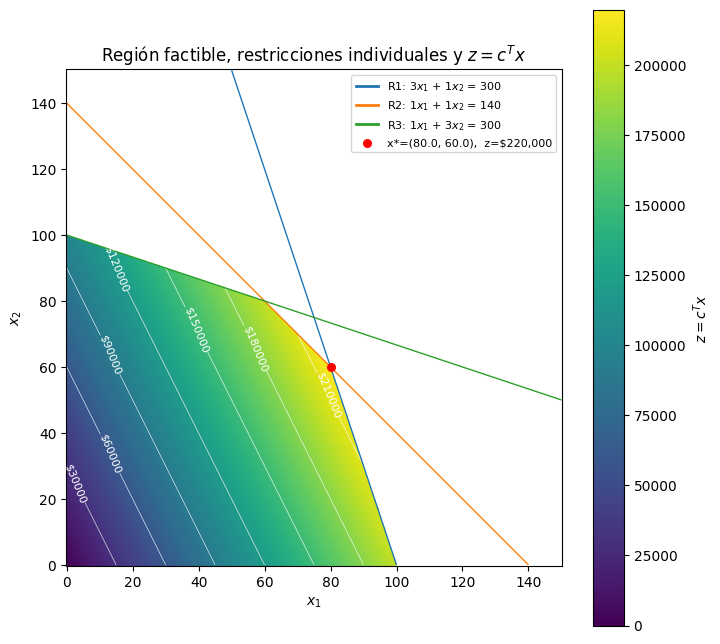

In [145]:
# Caso de la Floristería
A = np.array([[3, 1], [1, 1], [1, 3]])
b = np.array([300, 140, 300])
c = np.array([2000, 1000])
optimo = np.array([x_opt['x_1'], x_opt['x_2']]) # (x_1, x_2) = (80, 60)

ver_region_factible(A, b, c, x1_range=(0, 150), x2_range=(0, 150), punto=optimo)

In [146]:
ver_region_factible_3d(A, b, c, x1_range=(0, 150), x2_range=(0, 150), punto=optimo)